<a href="https://colab.research.google.com/github/AnujikaSasindi/sri-lanka-tourism-sentiment-analysis/blob/Main/Try_Again_2__Attraction_Prediction_Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installations**

In [30]:
import sys
import re
import warnings

%matplotlib inline

import matplotlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

**Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

# 2. Load the dataset - change 'your_file.csv' to your actual filename
df = pd.read_excel('balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx to balanced_cleaned_dataset_1_(sentiment + attarction category) (1).xlsx
Shape of dataset: (7164, 11)

Column names:
['Location_Name', 'Located_City', 'Location_Type', 'Title', 'Text', 'Review_Text', 'Rating', 'Sentiment', 'Cluster_Text', 'Attraction_Cluster', 'Attraction_Category']

First 5 rows:


,Location_Name,Located_City,Location_Type,Title,Text,Review_Text,Rating,Sentiment,Cluster_Text,Attraction_Cluster,Attraction_Category
0,Handunugoda Tea Estate,Ahangama,Farms,Wonderful Experience,This was our third tea factory tour during our...,Wonderful Experience This was our third tea fa...,5,Positive,Handunugoda Tea Estate Farms Wonderful Experie...,4,Tea Plantations & Factory Tours
1,Glenloch Tea Factory,Katukitula,Farms,In-TEA-resting,A worth visit for everyone who drinks tea. Gui...,In-TEA-resting A worth visit for everyone who ...,4,Positive,Glenloch Tea Factory Farms In-TEA-resting A wo...,4,Tea Plantations & Factory Tours
2,Handunugoda Tea Estate,Ahangama,Farms,"The best tea experience, great history","Hidden away in a beautiful stretch of green, t...","The best tea experience, great history Hidden ...",5,Positive,Handunugoda Tea Estate Farms The best tea expe...,4,Tea Plantations & Factory Tours
3,Bluefield Tea Gardens,Nuwara Eliya,Farms,Informative tour,We really enjoyed our tour at the Bluefield te...,Informative tour We really enjoyed our tour at...,5,Positive,Bluefield Tea Gardens Farms Informative tour W...,4,Tea Plantations & Factory Tours
4,Ceylon Tea Museum,Kandy,Museums,Under appreciated - well worth,We spend a few enjoyable hours here. It is aro...,Under appreciated - well worth We spend a few ...,4,Positive,Ceylon Tea Museum Museums Under appreciated - ...,4,Tea Plantations & Factory Tours


In [39]:
required = {"Title", "Text", "Attraction_Category"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

df = df.dropna(subset=["Title", "Text", "Attraction_Category"]).copy()

# Combine the three text fields into one document per review
df["combined_text"] = (
    df["Title"].astype(str) + " "
    + df["Text"].astype(str)
)

cleaned_texts = []
for text in df["combined_text"]:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    cleaned_texts.append(text)
df["combined_text"] = cleaned_texts

print(f"Loaded {len(df)} rows, {df['Attraction_Category'].nunique()} categories")
print(df["Attraction_Category"].value_counts())

Loaded 7164 rows, 6 categories
Attraction_Category
Gardens, Lakes & Waterfalls        1706
Temples & Religious Sites          1191
Wildlife & National Parks          1190
Museums & Historic Sites           1149
Beaches & Coastal Areas             970
Tea Plantations & Factory Tours     958
Name: count, dtype: int64


**Model Defining**

In [40]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Linear SVM": LinearSVC(
        random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
    ),
}

**Train + evaluate all models on a given split**

In [41]:
y = df["Attraction_Category"]
X_text = df["combined_text"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

label = "Random train/test split (80/20)"
print(f"\n{'='*70}")
print(f"  EXPERIMENT: {label}")
print(f"{'='*70}")
print(f"Train size: {len(X_train_text)}   Test size: {len(X_test_text)}")

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")
    f1_weighted = f1_score(y_test, preds, average="weighted")
    results[name] = {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}
    trained_models[name] = model
    print(f"\n{name}")
    print(f"  Accuracy:      {acc:.4f}")
    print(f"  F1 (macro):    {f1_macro:.4f}")
    print(f"  F1 (weighted): {f1_weighted:.4f}")

X_test_vec = X_test
y_test_main = y_test


  EXPERIMENT: Random train/test split (80/20)
Train size: 5731   Test size: 1433

Logistic Regression
  Accuracy:      0.9156
  F1 (macro):    0.9189
  F1 (weighted): 0.9157

Linear SVM
  Accuracy:      0.9135
  F1 (macro):    0.9163
  F1 (weighted): 0.9136

Multinomial Naive Bayes
  Accuracy:      0.8849
  F1 (macro):    0.8919
  F1 (weighted): 0.8853

Random Forest
  Accuracy:      0.8863
  F1 (macro):    0.8902
  F1 (weighted): 0.8857


**Pick best model and classification report**

In [42]:
best_name = max(results, key=lambda n: results[n]["f1_macro"])
best_model = trained_models[best_name]
print(f"\n>>> Best model (by macro F1): {best_name}")

best_preds = best_model.predict(X_test_vec)
labels = sorted(y.unique())
print("\nClassification report for best model:")
print(classification_report(y_test_main, best_preds, labels=labels))


>>> Best model (by macro F1): Logistic Regression

Classification report for best model:
                                 precision    recall  f1-score   support

        Beaches & Coastal Areas       0.97      0.94      0.96       194
    Gardens, Lakes & Waterfalls       0.89      0.92      0.90       341
       Museums & Historic Sites       0.87      0.86      0.86       230
Tea Plantations & Factory Tours       0.96      0.96      0.96       192
      Temples & Religious Sites       0.90      0.90      0.90       238
      Wildlife & National Parks       0.94      0.92      0.93       238

                       accuracy                           0.92      1433
                      macro avg       0.92      0.92      0.92      1433
                   weighted avg       0.92      0.92      0.92      1433



**Model comparison bar chart**

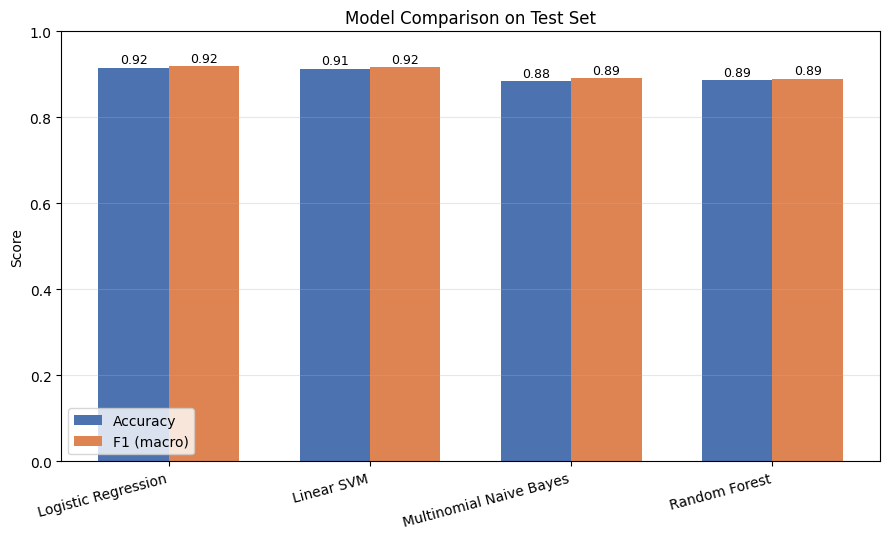


Saved: attraction_model_comparison_2.png


In [44]:
out_path = "attraction_model_comparison_2.png"

names = list(results.keys())
acc_vals = [results[n]["accuracy"] for n in names]
f1m_vals = [results[n]["f1_macro"] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - width / 2, acc_vals, width, label="Accuracy", color="#4C72B0")
ax.bar(x + width / 2, f1m_vals, width, label="F1 (macro)", color="#DD8452")

ax.set_ylabel("Score")
ax.set_title("Model Comparison on Test Set")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate(acc_vals):
    ax.text(i - width / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(f1m_vals):
    ax.text(i + width / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(out_path, dpi=150)
plt.show()
plt.close()
print(f"\nSaved: {out_path}")

**Confusion matrix for best model**

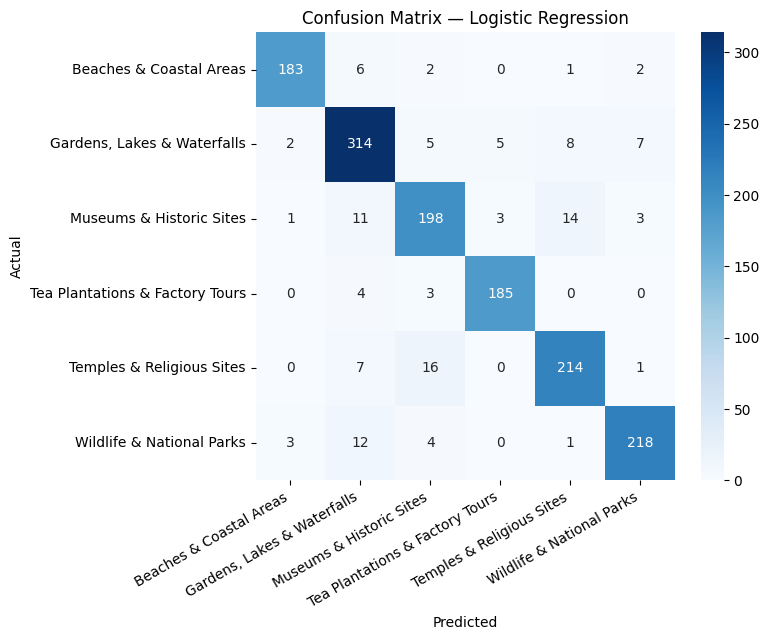

Saved: attarction_confusion_matrix_2.png


In [46]:
cm_out_path = "attarction_confusion_matrix_2.png"

cm = confusion_matrix(y_test_main, best_preds, labels=labels)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels, ax=ax, cbar=True,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(cm_out_path, dpi=150)
plt.show()  # displays inline in Colab
print(f"Saved: {cm_out_path}")

**Save the best model**

In [47]:
joblib.dump(
    {"model": best_model, "vectorizer": vectorizer, "model_name": best_name},
    "attarction_category_best_model_2.joblib",
)
print(f"\nSaved trained pipeline: attarction_category_best_model_2.joblib ({best_name})")

print("\nDone.")


Saved trained pipeline: attarction_category_best_model_2.joblib (Logistic Regression)

Done.
